# Exercise 6

## SVM & Regularization


For this homework we consider a set of observations on a number of red and white wine varieties involving their chemical properties and ranking by tasters. Wine industry shows a recent growth spurt as social drinking is on the rise. The price of wine depends on a rather abstract concept of wine appreciation by wine tasters, opinion among whom may have a high degree of variability. Pricing of wine depends on such a volatile factor to some extent. Another key factor in wine certification and quality assessment is physicochemical tests which are laboratory-based and takes into account factors like acidity, pH level, presence of sugar and other chemical properties. For the wine market, it would be of interest if human quality of tasting can be related to the chemical properties of wine so that certification and quality assessment and assurance process is more controlled.

Two datasets are available of which one dataset is on red wine and have 1599 different varieties and the other is on white wine and have 4898 varieties. All wines are produced in a particular area of Portugal. Data are collected on 12 different properties of the wines one of which is Quality, based on sensory data, and the rest are on chemical properties of the wines including density, acidity, alcohol content etc. All chemical properties of wines are continuous variables. Quality is an ordinal variable with possible ranking from 1 (worst) to 10 (best). Each variety of wine is tasted by three independent tasters and the final rank assigned is the median rank given by the tasters.

A predictive model developed on this data is expected to provide guidance to vineyards regarding quality and price expected on their produce without heavy reliance on volatility of wine tasters.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_r = pd.read_csv('https://github.com/albahnsen/PracticalMachineLearningClass/raw/master/datasets/Wine_data_red.csv')
data_w = pd.read_csv('https://github.com/albahnsen/PracticalMachineLearningClass/raw/master/datasets/Wine_data_white.csv')

In [3]:
data = data_w.assign(type = 'white')

data = pd.concat([data, data_r.assign(type = 'red')], ignore_index=True)
data.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
3647,6.4,0.29,0.24,3.20,0.037,31.0,95.0,0.98942,2.90,0.66,12.6,7,white
2259,7.2,0.39,0.54,1.40,0.157,34.0,132.0,0.99449,3.11,0.53,9.0,6,white
1908,7.2,0.36,0.36,5.70,0.038,26.0,98.0,0.99140,2.93,0.59,12.5,7,white
3962,7.2,0.58,0.27,5.80,0.032,40.0,118.0,0.99088,3.17,0.53,13.0,7,white
2775,7.0,0.36,0.32,10.05,0.045,37.0,131.0,0.99352,3.09,0.33,11.7,8,white


# Exercise 6.1

Show the frecuency table of the quality by type of wine

In [4]:
pd.crosstab(data["type"], data["quality"], margins=True)

quality,3,4,5,6,7,8,9,All
type,,,,,,,,
red,10,53,681,638,199,18,0,1599
white,20,163,1457,2198,880,175,5,4898
All,30,216,2138,2836,1079,193,5,6497


# SVM

# Exercise 6.2

* Standarized the features (not the quality)
* Create a binary target for each type of wine
* Create two Linear SVM's for the white and red wines, repectively.


In [5]:
redwine = data_r.drop("quality", axis=1)
redwine_labels = data_r["quality"].copy()

whitewine = data_w.drop("quality", axis=1)
whitewine_labels = data_w["quality"].copy()

## 6.2.1. Data Cleaning

From the frequency table, there is no missing value or duplicated value. We will focus only on removing outliers for the redwine only (because I'm lazy). Let's begin looking at some statistics.

In [6]:
redwine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


From the mean and std (standard deviation), we can see some attributes with the stds approximately half (e.g. citric acid) or two-thirds (e.g. free sulfur dioxide) the means. The maximum of some attributes also far from the 75th (e.g. residual sugar). These signs do warn about the existence of outliers. Take a look at some diagram also.

In [7]:
def draw_scatter_hist(data, data_labels):
    n_features = data.shape[1]

    fig, axs = plt.subplots(n_features, 2,
                            figsize=(3+2, n_features*3),
                            gridspec_kw={"width_ratios": [3, 2], "hspace": 0.15},
                            layout="constrained")

    for row, feature in zip(axs, data.columns):
        row[0].scatter(data[feature].to_numpy(), data_labels.to_numpy())
        row[0].set_xlabel(feature)
        row[0].set_ylabel(data_labels.name)

        row[1].hist(data[feature].to_numpy(), 30)

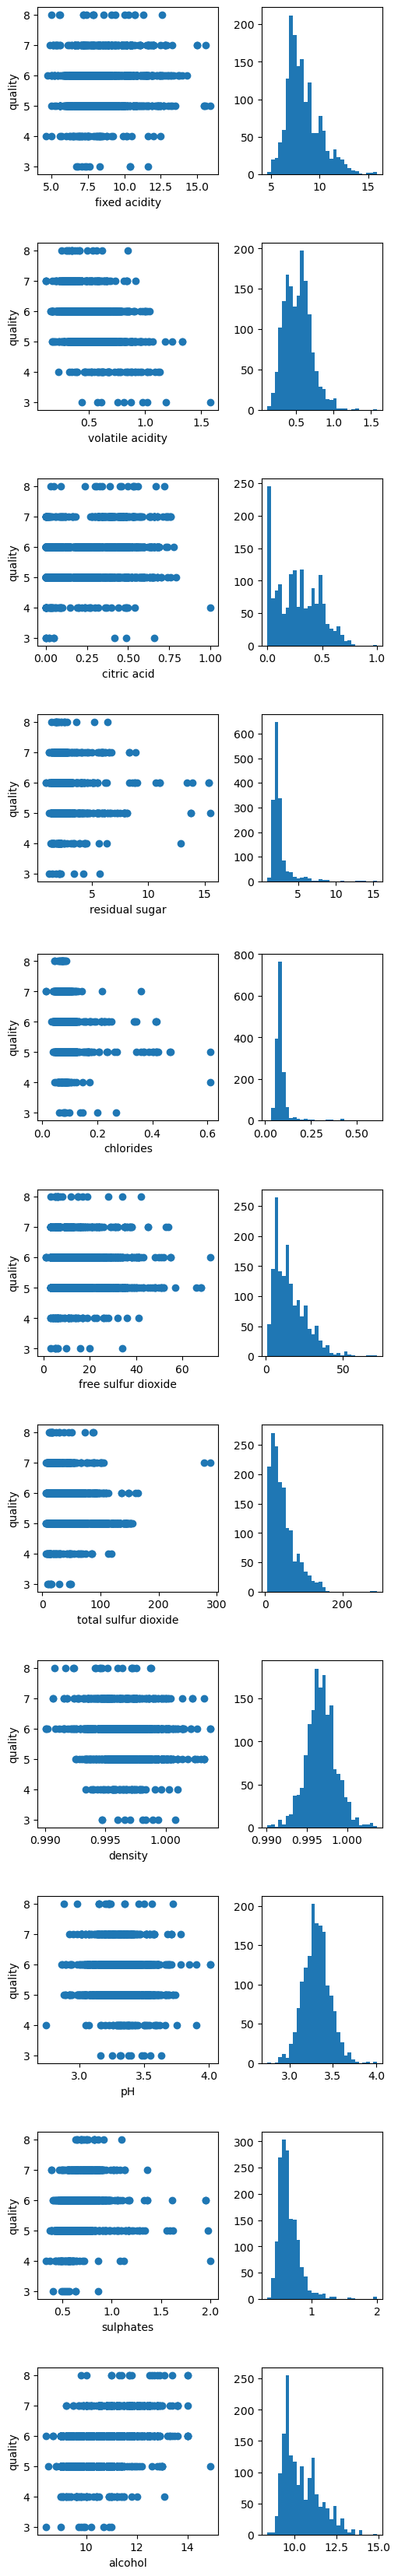

In [8]:
draw_scatter_hist(redwine, redwine_labels)

The diagrams and statistics do show outliers and this is some bad news cause we need work harder on the data. Outliers can be made by mistakes or the do represent some pattern of the real world, we are no expert of such domain to answer these questions, but there are general ways to define outliers for our statisticians. MLM has some writings about [Data Preparation](https://machinelearningmastery.com/start-here/#dataprep) which mention how to [handle outliers](https://machinelearningmastery.com/how-to-use-statistics-to-identify-outliers-in-data/). The two methods we will be using are:
- Standard Deviation method for cases where data have Gaussian distribution (Normal distribution).
- and Interquartile Range method for non-Gaussian distribution.

Our next step is to identify attributes with Gaussian distribution. There are tools like [`distfit` provided by Erdogan](https://erdogant.github.io/distfit/pages/html/index.html) which test your data on multiple distribution. But for the sake of simplicity and the cause of my laziness, I leave my visual ability to do the work. Changing the bin size of the historgram help you identify better the type of distribution. See the histograms below.

In [9]:
def draw_hist_variation(data):
    n_features = data.shape[1]
    
    fig, axs = plt.subplots(n_features, 4,
                            figsize=(2*4, n_features*3),
                            gridspec_kw={"hspace": 0.15},
                            layout="constrained")

    for row, feature in zip(axs, data.columns):
        row[0].hist(data[feature].to_numpy(), 10)
        row[0].set_title(f"{feature} (10 bins)")
        row[1].hist(data[feature].to_numpy(), 20)
        row[1].set_title("(20 bins)")
        row[2].hist(data[feature].to_numpy(), 30)
        row[2].set_title("(30 bins)")
        row[3].hist(data[feature].to_numpy(), 40)
        row[3].set_title("(40 bins)")

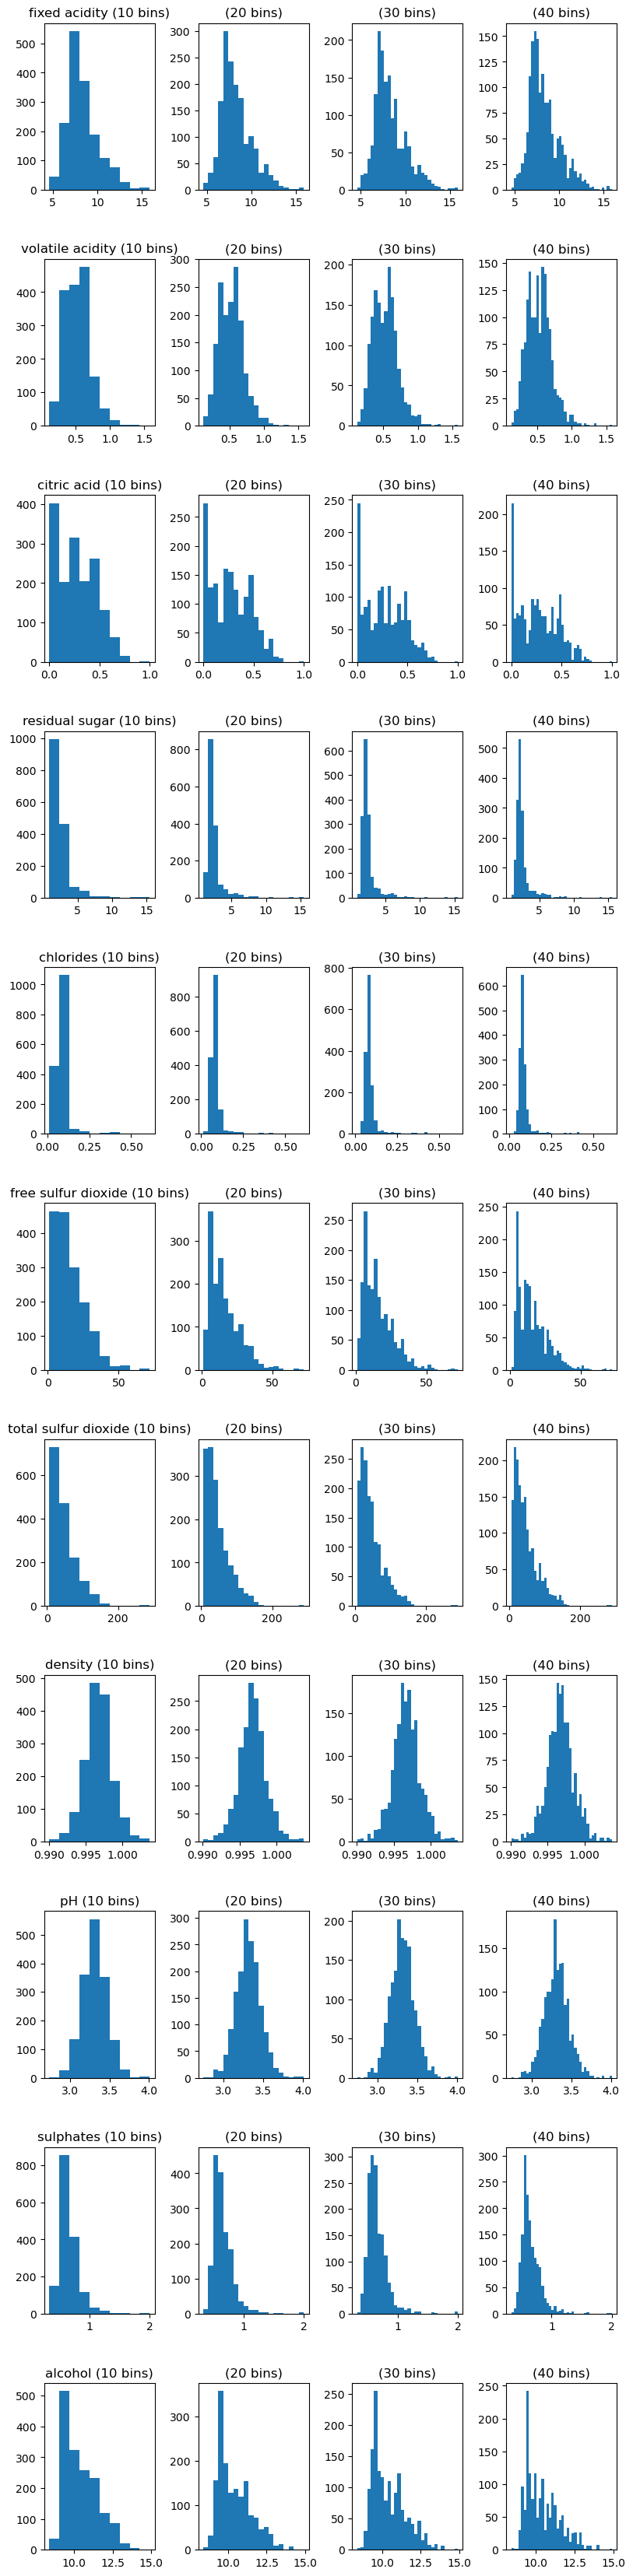

In [10]:
draw_hist_variation(redwine)

Here is the result of my hard work:

- **Gaussian:** "volatile acidity", "chlorides", "density", "pH", "sulphates"
- **Gamma (close Exponential):** "fixed acidity", "alcohol"
- **Exponential:** "citric acid", "residual sugar", "free sulfur dioxide", "total sulfur dioxide"

Distribution of "citric acid" is noisy with many peaks, but I don't know what to do with it so just ignore it.

We will apply the **Standard Deviation Method** for features approximating Gaussian distribution (Normal distribution), while **Interquartile Range Method** for non-Gaussian features. Look at the implementation below.

In [11]:
red_gaussian_features = ["volatile acidity", "chlorides", "density", "pH", "sulphates"]
red_nongauss_features = [ft for ft in redwine.columns if ft not in red_gaussian_features]

In [12]:
# 1st remove outliers: Standard deviation method
redwine_mean = redwine.mean(axis=0)
redwine_std = redwine.std(axis=0)

gaussian_no_outlier_mask = pd.Series(np.ones(redwine.shape[0], dtype=bool)) 
for ft in red_gaussian_features:
    lower = redwine_mean[ft] - 3*redwine_std[ft]
    upper = redwine_mean[ft] + 3*redwine_std[ft]

    filter_mask = (redwine[ft] > lower) & (redwine[ft] < upper)
    gaussian_no_outlier_mask *= filter_mask

gaussian_no_outlier_mask.value_counts()

True     1518
False      81
Name: count, dtype: int64

In [13]:
# 2nd remove outliers: Interquartile Range Method
redwine_75th = redwine.describe().loc["75%"]
redwine_25th = redwine.describe().loc["25%"]
redwine_iqr = redwine_75th - redwine_25th

iqr_range_mask = pd.Series(np.ones(redwine.shape[0], dtype=bool)) 
for ft in red_nongauss_features:
    lower = redwine_25th[ft] - 1.5*redwine_iqr[ft]
    upper = redwine_75th[ft] + 1.5*redwine_iqr[ft]

    filter_mask = (redwine[ft] > lower) & (redwine[ft] < upper)
    iqr_range_mask *= filter_mask

iqr_range_mask.value_counts()

True     1338
False     261
Name: count, dtype: int64

In [14]:
no_outlier_mask = gaussian_no_outlier_mask * iqr_range_mask
no_outlier_mask.value_counts()

True     1283
False     316
Name: count, dtype: int64

In [15]:
cleaned_redwine = redwine[no_outlier_mask]
cleaned_redwine_labels = redwine_labels[no_outlier_mask]

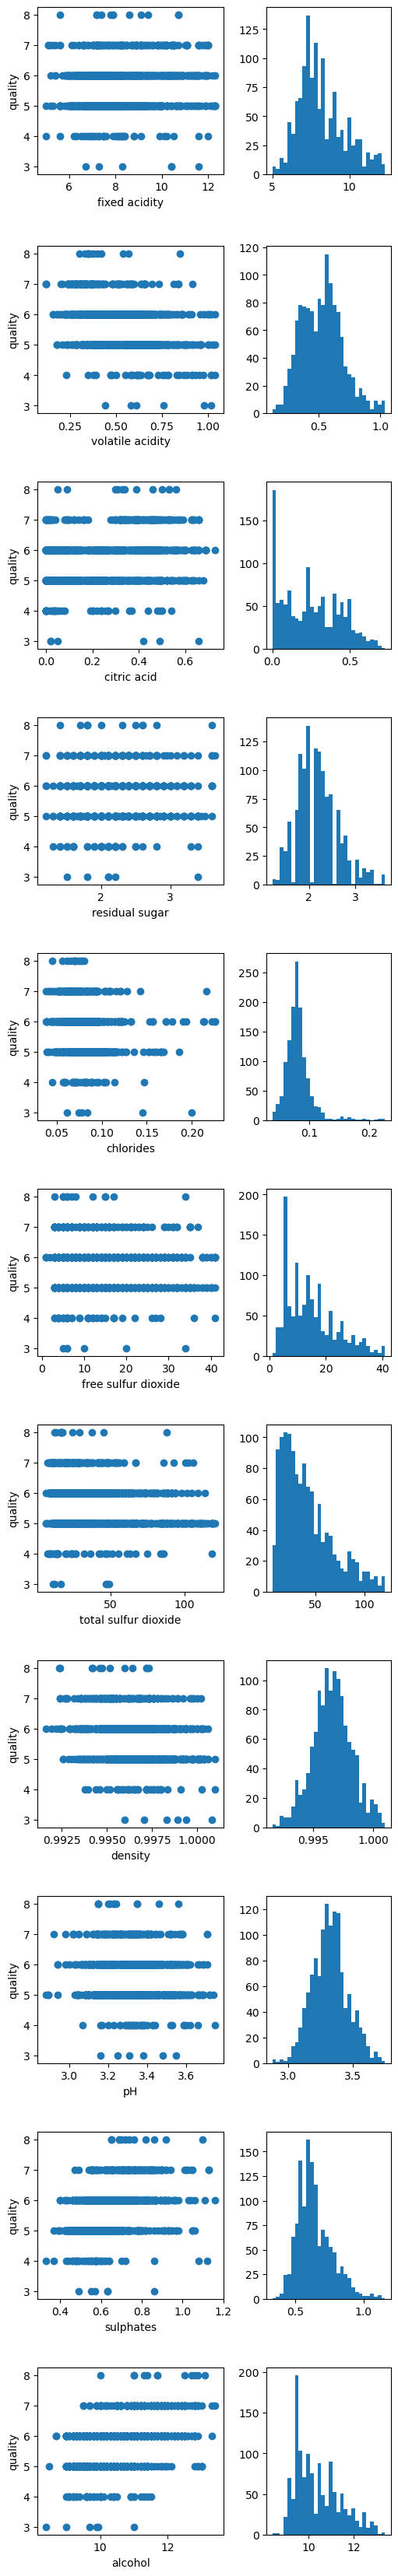

In [16]:
draw_scatter_hist(cleaned_redwine, cleaned_redwine_labels)

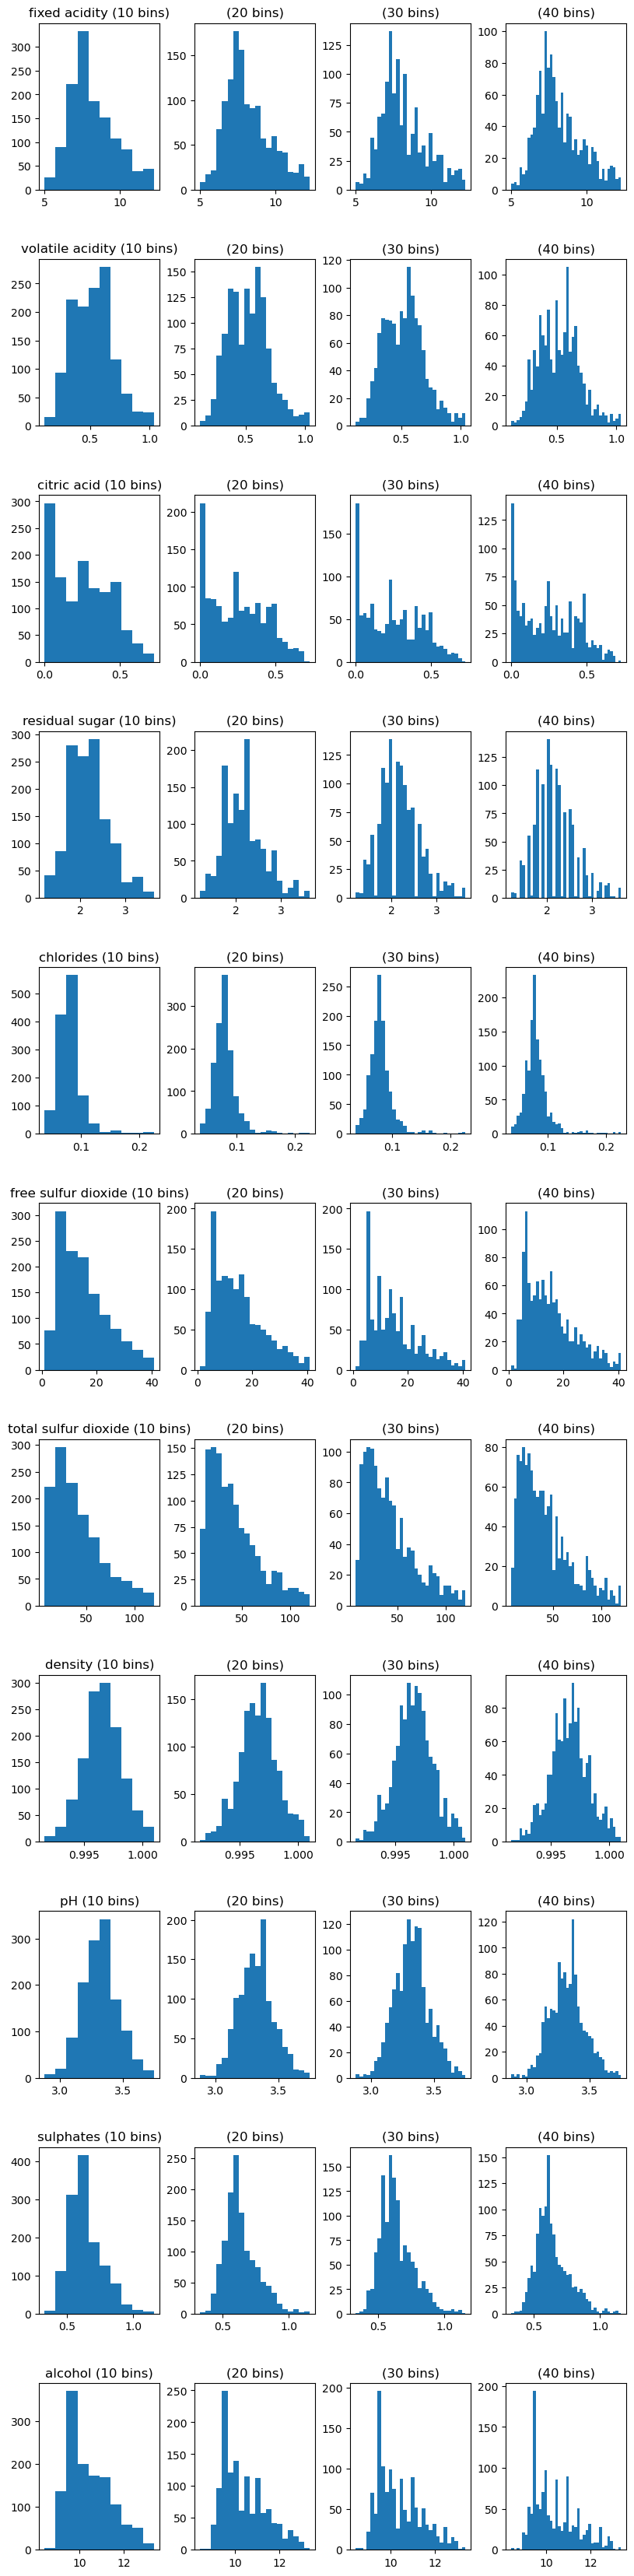

In [17]:
draw_hist_variation(cleaned_redwine)

We have removed 316 rows of 1599 rows, equal to 19.76% of the data size. Hope this red wine dataset would perform better than the white wine dataset (4898 rows of data).

Let's have a look at the white wine dataset below for more information in the next step.

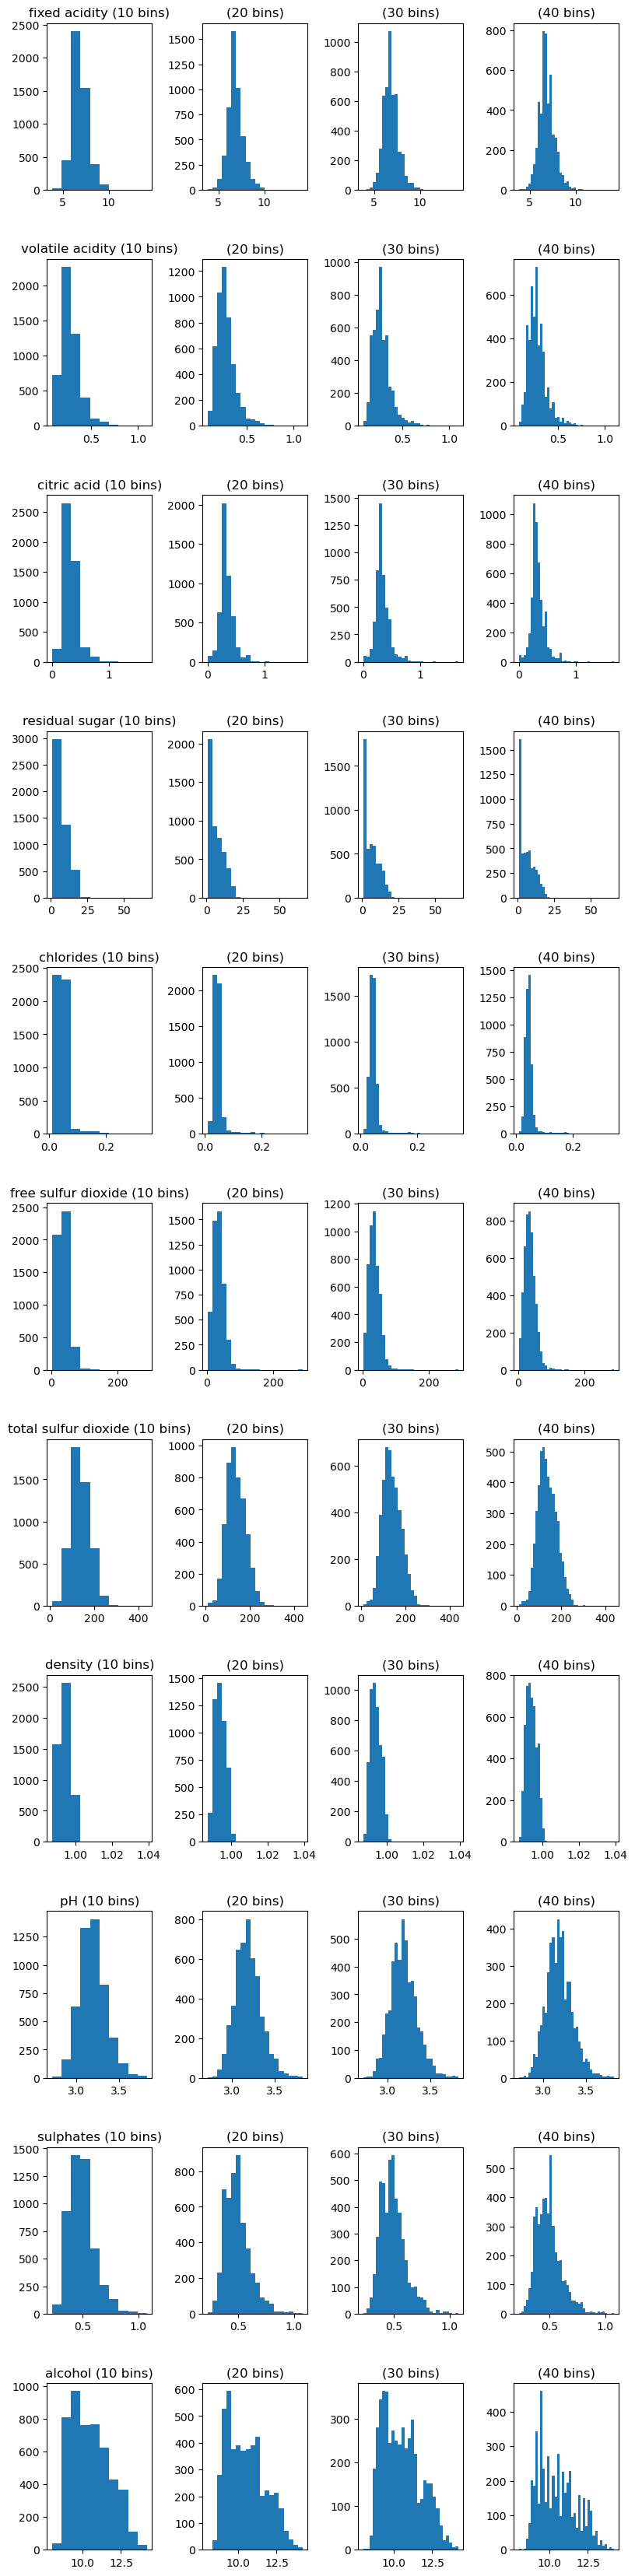

In [23]:
draw_hist_variation(whitewine)

## 6.2.2. Handling Text and Categorical Attributes

All chemical properties of wine are continous variables.

## 6.2.3. Feature Scaling

Feature scaling is an important preprocessing step for many machine learning algorithms. See how Google MLCC write about [different normalization methods](https://developers.google.com/machine-learning/crash-course/numerical-data/normalization), scikit-learn documentation also includes implementations about [model performance with and without feature scalling](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html).

If some outliers are present in the set, their impact on model performance should be considered. Scikit-learn wrote about [the effect of outliers on the feature scaling](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py) step. In our case, we have done defining the outliners statistically and removing them. Now we can learn how to normalized our data.

Z-score scaling is suitable for a "vaguely" normal distribution, and the above histograms all look more like normal distributions to me. Let's do the normalization for both cleaned red wine and white wine dataset.

In [29]:
redwine_mean = cleaned_redwine.mean()
redwine_std = cleaned_redwine.std()
scaled_redwine = (cleaned_redwine - redwine_mean) / redwine_std

whitewine_mean = whitewine.mean()
whitewine_std = whitewine.std()
scaled_whitewine = (whitewine - whitewine_mean) / whitewine_std

In [30]:
scaled_whitewine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03,4.898000e+03
mean,-3.481630e-16,4.468092e-16,2.321087e-17,-1.109770e-16,3.075440e-16,-1.378145e-17,-4.642174e-17,3.244880e-14,-1.195360e-15,-8.218098e-16,3.017413e-16
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.619982e+00,-1.966784e+00,-2.761461e+00,-1.141827e+00,-1.683102e+00,-1.958477e+00,-3.043919e+00,-2.312802e+00,-3.101091e+00,-2.364468e+00,-2.043089e+00
25%,-6.574340e-01,-6.770318e-01,-5.304215e-01,-9.249530e-01,-4.472890e-01,-7.237012e-01,-7.144009e-01,-7.706280e-01,-6.507699e-01,-6.996389e-01,-8.241915e-01
50%,-6.492444e-02,-1.809733e-01,-1.172660e-01,-2.348977e-01,-1.268931e-01,-7.691388e-02,-1.026084e-01,-9.608339e-02,-5.474574e-02,-1.739035e-01,-9.285319e-02
75%,5.275851e-01,4.142970e-01,4.611517e-01,6.917479e-01,1.935028e-01,6.286722e-01,6.738976e-01,6.929749e-01,6.075033e-01,5.270772e-01,7.197450e-01
max,8.704217e+00,8.152811e+00,1.095530e+01,1.171292e+01,1.374167e+01,1.491679e+01,7.097720e+00,1.502976e+01,4.183648e+00,5.171074e+00,2.995020e+00


After feature scaling, we can see in the summary description of the white wine dataset, there are features with the maximum value 7, 8, or 9 times the standard deviation. From what we have read in the scikit-learn documentation, the Z-score scaling (Standardization) is sensitive to outliners and therefore it is important to do handle outliers in the data cleaning process appropriately.

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>, <Axes: >]], dtype=object)

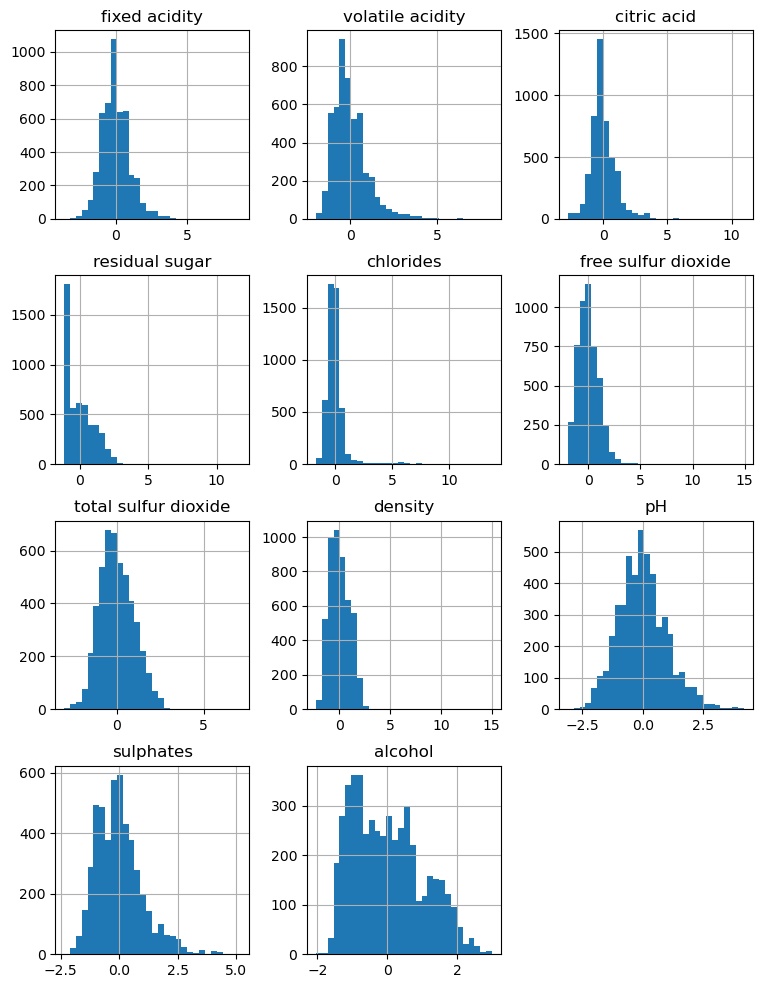

In [41]:
scaled_whitewine.hist(bins=30, figsize=(3*3, 4*3), )

## 6.2.4. Create Test Set

We are a bit late when doing train-test split for our dataset at this step.

After reading the book *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, I know that the train-test split should be done after we load the data, and BEFORE we do any further visualization and analysis because out brain might detect some pattern of the current dataset and do the data processing and modeling with a bias, in a way that we overfit the test data instead of generalizing our mode. And this is called *data snopping*.

Another problem we should consider is *sampling bias*, which is when we split the data randomly with a small dataset (w.r.t. the number of features) and the samples of the test set does not represent the full scope of your domain (e.g. imbalanced dataset). The approach for this is called *stratified sampling*. Suppose you chatted with an experts who told you that the color and the smell of the wine are some distinctive features for recognizing the quality, or you looked at the scatter plot above which show you the linear relationship of alcohol and sulphates to wine quality. You may want to ensure your test set contains different representative samples from these features.

Well, I'm too lazy to care about such things, so why don't we just do some train-test split right now, shall we?

In [ ]:
# Set seed
np.random.seed(42)

def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

red_data = pd.concat([scaled_redwine, cleaned_redwine_labels], axis=1)
white_data = pd.concat([scaled_whitewine, whitewine_labels], axis=1)

red_train, red_test = split_train_test(red_data, 0.2)
white_train, white_test = split_train_test(white_data, 0.2)

In [47]:
red_train_X = red_train.drop("quality", axis=1)
red_train_y = red_train["quality"].copy()

white_train_X = white_train.drop("quality", axis=1)
white_train_y = white_train["quality"].copy()

In [48]:
red_train_X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1583,-1.322465,-0.380636,0.207083,-0.183003,-0.329624,1.955350,2.188846,-0.491555,0.045441,-0.157482,-0.591329
182,-0.659476,1.210771,-1.259606,0.710596,-0.236962,0.143023,0.024699,0.378320,0.836200,-0.943054,-1.096685
1191,-1.123569,2.124357,-1.368249,0.263796,3.932807,-0.989682,-1.134665,-0.656954,1.698845,-1.021611,0.419384
368,1.395792,-1.087928,1.456485,1.380795,3.608492,0.029752,1.300000,1.971049,-1.032867,-0.000367,-0.995614
712,0.335009,0.975007,-1.368249,2.274394,0.133684,-0.196789,-0.323110,1.603496,0.261102,-1.492954,-0.995614


How about data transformation before, or after train-test split? Does it matter? We may continue later...

# Exercise 6.3

Test the two SVM's using the different kernels (‘poly’, ‘rbf’, ‘sigmoid’)


In [ ]:

# redwine = data_r.drop("quality", axis=1)
# redwine_labels = data_r["quality"].copy()

# whitewine = data_w.drop("quality", axis=1)
# whitewine_labels = data_w["quality"].copy()

# cleaned_redwine = redwine[no_outlier_mask]
# cleaned_redwine_labels = redwine_labels[no_outlier_mask]

from sklearn.svm import SVC

red_clf = LinearSVC(loss="hinge")
red_clf.fit(scaled_redwine, cleaned_redwine_labels)

c:\dev\miniconda3\envs\practical-ml\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random numbe

In [33]:
white_clf = LinearSVC(loss='hinge')
white_clf.fit(scaled_whitewine, whitewine_labels)

c:\dev\miniconda3\envs\practical-ml\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random numbe

# Exercise 6.4
Using the best SVM find the parameters that gives the best performance

'C': [0.1, 1, 10, 100, 1000], 'gamma': [0.01, 0.001, 0.0001]

# Exercise 6.5

Compare the results with other methods

# Regularization

# Exercise 6.6


* Train a linear regression to predict wine quality (Continous)

* Analyze the coefficients

* Evaluate the RMSE

# Exercise 6.7

* Estimate a ridge regression with alpha equals 0.1 and 1.
* Compare the coefficients with the linear regression
* Evaluate the RMSE

# Exercise 6.8

* Estimate a lasso regression with alpha equals 0.01, 0.1 and 1.
* Compare the coefficients with the linear regression
* Evaluate the RMSE

# Exercise 6.9

* Create a binary target

* Train a logistic regression to predict wine quality (binary)

* Analyze the coefficients

* Evaluate the f1score

# Exercise 6.10

* Estimate a regularized logistic regression using:
* C = 0.01, 0.1 & 1.0
* penalty = ['l1, 'l2']
* Compare the coefficients and the f1score